<a href="https://colab.research.google.com/github/zeynepdanis/Neural-Network/blob/main/PNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
class PNN:
    def __init__(self, sigma=0.5):
        self.sigma = sigma          # yayılma (smoothing) parametresi
        self.X_train = None
        self.y_train = None
        self.classes_ = None

    # ── Eğitim: PNN'de eğitim sadece veriyi ezberlemektir ──
    def fit(self, X, y):
        self.X_train = np.array(X, dtype=float)
        self.y_train = np.array(y)
        self.classes_ = np.unique(y)
        return self

    # ── Gauss çekirdeği ──
    def _gaussian(self, D):
        return np.exp(- (D ** 2) / (2 * self.sigma ** 2))

    # ── Tek örnek için sınıf yoğunlukları ──
    def _class_densities(self, x):
        densities = {}
        for k in self.classes_:
            # k. sınıfa ait eğitim örnekleri
            mask = self.y_train == k
            X_k  = self.X_train[mask]
            N_k  = len(X_k)

            # Öklid uzaklıkları  →  Gauss değerleri
            D_t = np.sqrt(np.sum((X_k - x) ** 2, axis=1))   # (N_k,)
            G_t = self._gaussian(D_t)

            densities[k] = G_t.sum() / N_k
        return densities

    # ── Tahmin (tek veya çoklu örnek) ──
    def predict(self, X):
        X = np.array(X, dtype=float)
        preds = []
        for x in X:
            dens = self._class_densities(x)
            preds.append(max(dens, key=dens.get))
        return np.array(preds)

    # ── Her sınıf için yoğunluk değerleri (olasılığa benzer) ──
    def predict_proba(self, X):
        X = np.array(X, dtype=float)
        proba = []
        for x in X:
            dens  = self._class_densities(x)
            total = sum(dens.values())
            proba.append([dens[k] / total for k in self.classes_])
        return np.array(proba)


In [ ]:
def plot_confusion_matrix(cm, classes, title="Hata Matrisi"):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                linewidths=.5, cbar=False)
    plt.ylabel('Gerçek Sınıf')
    plt.xlabel('Tahmin Edilen Sınıf')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def performance_report(y_true, y_pred, classes):
    cm  = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    print("=" * 50)
    print("         PERFORMANS RAPORU")
    print("=" * 50)
    print(f"\n Doğruluk (Accuracy) : {acc:.4f}  ({acc*100:.2f}%)\n")
    print("─" * 50)
    print(classification_report(y_true, y_pred,
                                 target_names=[f"Sınıf {c}" for c in classes]))
    print("─" * 50)
    print("Hata Matrisi:\n")
    cm_df = pd.DataFrame(cm,
                         index  =[f"Gerçek {c}"   for c in classes],
                         columns=[f"Tahmin {c}" for c in classes])
    print(cm_df)
    print("=" * 50)
    plot_confusion_matrix(cm, classes)
    return cm, acc


   XOR PROBLEMİ — PNN ÇÖZÜMÜ

Test noktası: x = [0. 1.]
σ = 0.5

t  | x1_t  x2_t | D_t      | G_t
------------------------------------------
t=1| 0      0    | 1.0000   | 0.1353   → C0
t=2| 0      1    | 0.0000   | 1.0000   → C1
t=3| 1      0    | 1.4142   | 0.0183   → C1
t=4| 1      1    | 1.0000   | 0.1353   → C0

f0(x) = 0.1353
f1(x) = 0.5092

Tahmin: ŷ = argmax f_k(x) → Sınıf 1  ✓

──────────────────────────────────────────────────
Tüm XOR noktaları için tahminler:

 x1  x2  Gerçek  Tahmin Doğru mu?
0.0 0.0       0       0         ✓
0.0 1.0       1       1         ✓
1.0 0.0       1       1         ✓
1.0 1.0       0       0         ✓

         PERFORMANS RAPORU

 Doğruluk (Accuracy) : 1.0000  (100.00%)

──────────────────────────────────────────────────
              precision    recall  f1-score   support

     Sınıf 0       1.00      1.00      1.00         2
     Sınıf 1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg  

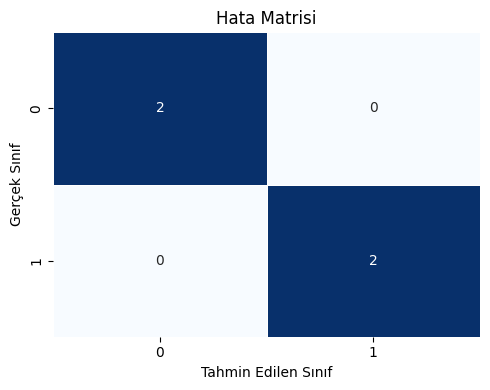

In [ ]:
print("\n" + "="*50)
print("   XOR PROBLEMİ — PNN ÇÖZÜMÜ")
print("="*50)

# Veri seti
X_xor = np.array([[0, 0],
                   [0, 1],
                   [1, 0],
                   [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

# ── Model ──
sigma = 0.5
model = PNN(sigma=sigma)
model.fit(X_xor, y_xor)

# ── Adım adım hesaplama (PDF örneğini doğrulama) ──
x_test_single = np.array([0, 1], dtype=float)
print(f"\nTest noktası: x = {x_test_single}")
print(f"σ = {sigma}\n")

print("t  | x1_t  x2_t | D_t      | G_t")
print("-" * 42)
for t, (xt, yt) in enumerate(zip(X_xor, y_xor), start=1):
    D_t = np.sqrt(np.sum((xt - x_test_single)**2))
    G_t = np.exp(-(D_t**2) / (2 * sigma**2))
    print(f"t={t}| {xt[0]:.0f}      {xt[1]:.0f}    | {D_t:.4f}   | {G_t:.4f}   → C{yt}")

densities = model._class_densities(x_test_single)
print(f"\nf0(x) = {densities[0]:.4f}")
print(f"f1(x) = {densities[1]:.4f}")
pred_single = model.predict([x_test_single])[0]
print(f"\nTahmin: ŷ = argmax f_k(x) → Sınıf {pred_single}  ✓")

# ── Tüm XOR noktaları için tahmin ──
print("\n" + "─"*50)
print("Tüm XOR noktaları için tahminler:\n")
y_pred = model.predict(X_xor)

df_result = pd.DataFrame(X_xor, columns=["x1", "x2"])
df_result["Gerçek"]  = y_xor
df_result["Tahmin"]  = y_pred
df_result["Doğru mu?"] = ["✓" if a == b else "✗"
                            for a, b in zip(y_xor, y_pred)]
print(df_result.to_string(index=False))

# ── Performans Raporu ──
print()
cm, acc = performance_report(y_xor, y_pred, model.classes_)
